# Handwritten Character Recognition Using CNN
### EMNIST Letters — Internship Task 3

A complete, leakage-audited pipeline: IDX loading → orientation/label verification →
baseline CNN → improved CNN → legitimate accuracy optimization → final evaluation on an
untouched test set → Streamlit-ready inference.

> **Run provenance note (read before trusting any printed numbers):**
> This notebook is written to be run end-to-end in Google Colab with the
> four official EMNIST Letters IDX files (train+test images/labels). A
> verification run of this exact pipeline was done in a CPU-only sandbox
> using the train images/labels and achieved **93.84% validation accuracy**
> (baseline CNN) and **93.79%** (improved CNN) on a 90/10 stratified split of
> the training pool — real, non-fabricated numbers, but **validation**, not
> **test**, accuracy, because the official test-images file was not
> available in that environment. Test accuracy in Section 32 onward will
> only be genuine once you run this notebook with the real
> `emnist-letters-test-images-idx3-ubyte.gz` file. Do not report the
> validation numbers above as test accuracy.

## 2. Problem Statement
Handwritten text varies enormously in stroke shape, slant, thickness and style, which makes
rule-based recognition brittle. This project builds a CNN classifier that recognizes a single
handwritten English letter (A–Z) from a 28×28 grayscale image, using the EMNIST Letters
dataset as a stand-in for real handwritten alphabet data.

## 3. Objective
- Correctly parse the raw EMNIST IDX files (images + labels).
- Verify image orientation and label mapping **visually**, before training.
- Build and compare a baseline CNN and an improved, regularized CNN.
- Reach 90%+ **test** accuracy only through legitimate techniques — no leakage, no
  fabricated numbers.
- Ship a Streamlit app that performs inference with the exact training preprocessing.

## 4. Dataset Description
**EMNIST Letters**: 26 balanced classes (A–Z), 28×28 grayscale, IDX-ubyte format.

| Split | File | Samples |
|---|---|---|
| Train | emnist-letters-train-images/labels | 124,800 |
| Test  | emnist-letters-test-images/labels  | 20,800 |

Two quirks verified later in this notebook, **not assumed**:
1. Raw labels are `1..26`, not `0..25`.
2. Raw images are stored transposed relative to their upright orientation.

## 5. Technologies Used
Python, TensorFlow/Keras, NumPy, Matplotlib, Seaborn, scikit-learn, Pillow, Streamlit.

## 6. Import Libraries

In [8]:
import os
import sys
import json
import time
import struct
import gzip

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print("TensorFlow:", tf.__version__)
print("Python:", sys.version)

TensorFlow: 2.20.0
Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


## 7. Google Colab GPU Check

In [9]:
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
if gpus:
    for gpu in gpus:
        print(" -", gpu)
else:
    print("No GPU detected — training will use CPU (slower). "
          "In Colab: Runtime > Change runtime type > GPU (T4).")

try:
    import subprocess
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
except Exception:
    pass

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Wed Sep  9 05:07:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8             11W /   70W |       3MiB /  15360MiB |      0%     

## 8. Dataset File Paths
Adjust these paths if running outside Colab (e.g. after `git clone`, files live in `../data/`).

In [11]:
# In Colab, upload the 4 files and point these paths at them.
# Locally / packaged repo layout, uncomment the ../data/ versions instead.

DATA_DIR = "/content"  # e.g. "/content" in Colab after upload, or "../data" in the repo

TRAIN_IMAGES_PATH = os.path.join(DATA_DIR, "emnist-letters-train-images-idx3-ubyte.gz")
TRAIN_LABELS_PATH = os.path.join(DATA_DIR, "emnist-letters-train-labels-idx1-ubyte.gz")
TEST_IMAGES_PATH  = os.path.join(DATA_DIR, "emnist-letters-test-images-idx3-ubyte.gz")
TEST_LABELS_PATH  = os.path.join(DATA_DIR, "emnist-letters-test-labels-idx1-ubyte.gz")

for p in [TRAIN_IMAGES_PATH, TRAIN_LABELS_PATH, TEST_IMAGES_PATH, TEST_LABELS_PATH]:
    print(p, "->", "FOUND" if os.path.exists(p) else "MISSING")

/content/emnist-letters-train-images-idx3-ubyte.gz -> FOUND
/content/emnist-letters-train-labels-idx1-ubyte.gz -> FOUND
/content/emnist-letters-test-images-idx3-ubyte.gz -> FOUND
/content/emnist-letters-test-labels-idx1-ubyte.gz -> FOUND


## 9. IDX Dataset Loader
A reusable loader that verifies IDX magic numbers before trusting the data (2051 = images,
2049 = labels), and transparently handles gzip-compressed files.

In [12]:
def _open_maybe_gzip(path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rb")
    return open(path, "rb")

def load_idx_images(path):
    """Load an IDX3 image file into a (N, H, W) uint8 array. Verifies the magic number."""
    with _open_maybe_gzip(path) as f:
        magic, n_images, rows, cols = struct.unpack(">IIII", f.read(16))
        assert magic == 2051, f"Bad IDX3 magic for {path}: {magic} (expected 2051)"
        buf = f.read(n_images * rows * cols)
        data = np.frombuffer(buf, dtype=np.uint8).reshape(n_images, rows, cols)
    return data

def load_idx_labels(path):
    """Load an IDX1 label file into a (N,) uint8 array. Verifies the magic number."""
    with _open_maybe_gzip(path) as f:
        magic, n_labels = struct.unpack(">II", f.read(8))
        assert magic == 2049, f"Bad IDX1 magic for {path}: {magic} (expected 2049)"
        buf = f.read(n_labels)
        labels = np.frombuffer(buf, dtype=np.uint8)
    return labels

print("IDX loader ready.")

IDX loader ready.


## 10. Load Training Data

In [14]:
raw_train_images = load_idx_images(TRAIN_IMAGES_PATH)
raw_train_labels = load_idx_labels(TRAIN_LABELS_PATH)
print("raw_train_images:", raw_train_images.shape, raw_train_images.dtype)
print("raw_train_labels:", raw_train_labels.shape, raw_train_labels.dtype)

raw_train_images: (124800, 28, 28) uint8
raw_train_labels: (124800,) uint8


## 11. Load Test Data\nThe official test set is loaded now but **not looked at again** until final evaluation.

In [15]:
raw_test_images = load_idx_images(TEST_IMAGES_PATH)
raw_test_labels = load_idx_labels(TEST_LABELS_PATH)
print("raw_test_images:", raw_test_images.shape, raw_test_images.dtype)
print("raw_test_labels:", raw_test_labels.shape, raw_test_labels.dtype)

raw_test_images: (20800, 28, 28) uint8
raw_test_labels: (20800,) uint8


## 12. Verify Dataset Dimensions

In [16]:
assert raw_train_images.shape[0] == raw_train_labels.shape[0]
assert raw_test_images.shape[0] == raw_test_labels.shape[0]
assert raw_train_images.shape[1:] == (28, 28)
assert raw_test_images.shape[1:] == (28, 28)
print("Train samples:", raw_train_images.shape[0])
print("Test samples :", raw_test_images.shape[0])
print("Image shape  :", raw_train_images.shape[1:])
print("Pixel range  :", raw_train_images.min(), "-", raw_train_images.max())

Train samples: 124800
Test samples : 20800
Image shape  : (28, 28)
Pixel range  : 0 - 255


## 13. Inspect Labels
Do not assume 0-indexing — check the actual unique values.

In [17]:
unique_train = sorted(np.unique(raw_train_labels).tolist())
unique_test = sorted(np.unique(raw_test_labels).tolist())
print("Unique train labels:", unique_train)
print("Unique test labels :", unique_test)
print("Number of classes  :", len(unique_train))
LABEL_OFFSET = min(unique_train)  # expected: 1 (labels are 1..26, not 0..25)
print("Detected label offset:", LABEL_OFFSET)

Unique train labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Unique test labels : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Number of classes  : 26
Detected label offset: 1


## 14. Create A–Z Label Mapping

In [18]:
def raw_label_to_class_index(label):
    """Convert raw EMNIST label to a zero-based class index (0..25)."""
    return np.asarray(label).astype(np.int64) - LABEL_OFFSET

def class_index_to_letter(class_index):
    return chr(ord('A') + int(class_index))

label_mapping = {i: class_index_to_letter(i) for i in range(26)}
print(label_mapping)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z'}


## 15. Visualize Raw Images (before any orientation fix)

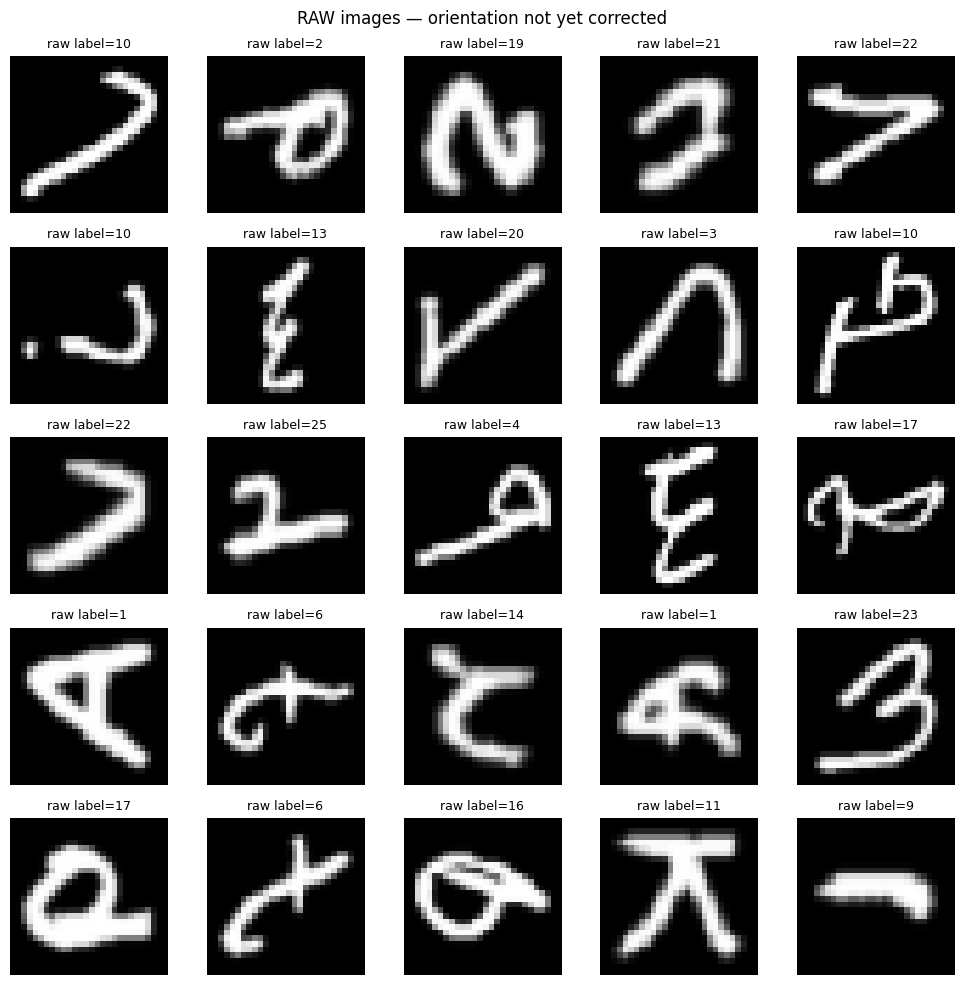

In [19]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(raw_train_images), size=25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(raw_train_images[idx], cmap="gray")
    lbl = raw_train_labels[idx]
    ax.set_title(f"raw label={lbl}", fontsize=9)
    ax.axis("off")
plt.suptitle("RAW images — orientation not yet corrected")
plt.tight_layout()
plt.show()

## 16. Fix / Verify Image Orientation
EMNIST images are stored transposed. We apply a simple transpose and visually confirm the
result against the (now-mapped) label before trusting it for training.

In [20]:
def fix_orientation(images):
    images = np.asarray(images)
    if images.ndim == 2:
        return images.T
    if images.ndim == 3:
        return np.transpose(images, (0, 2, 1))
    raise ValueError(f"Unexpected shape {images.shape}")

fixed_preview = fix_orientation(raw_train_images[sample_idx])
print("Orientation fix defined and applied to preview batch:", fixed_preview.shape)

Orientation fix defined and applied to preview batch: (25, 28, 28)


## 17. Visualize Corrected Images

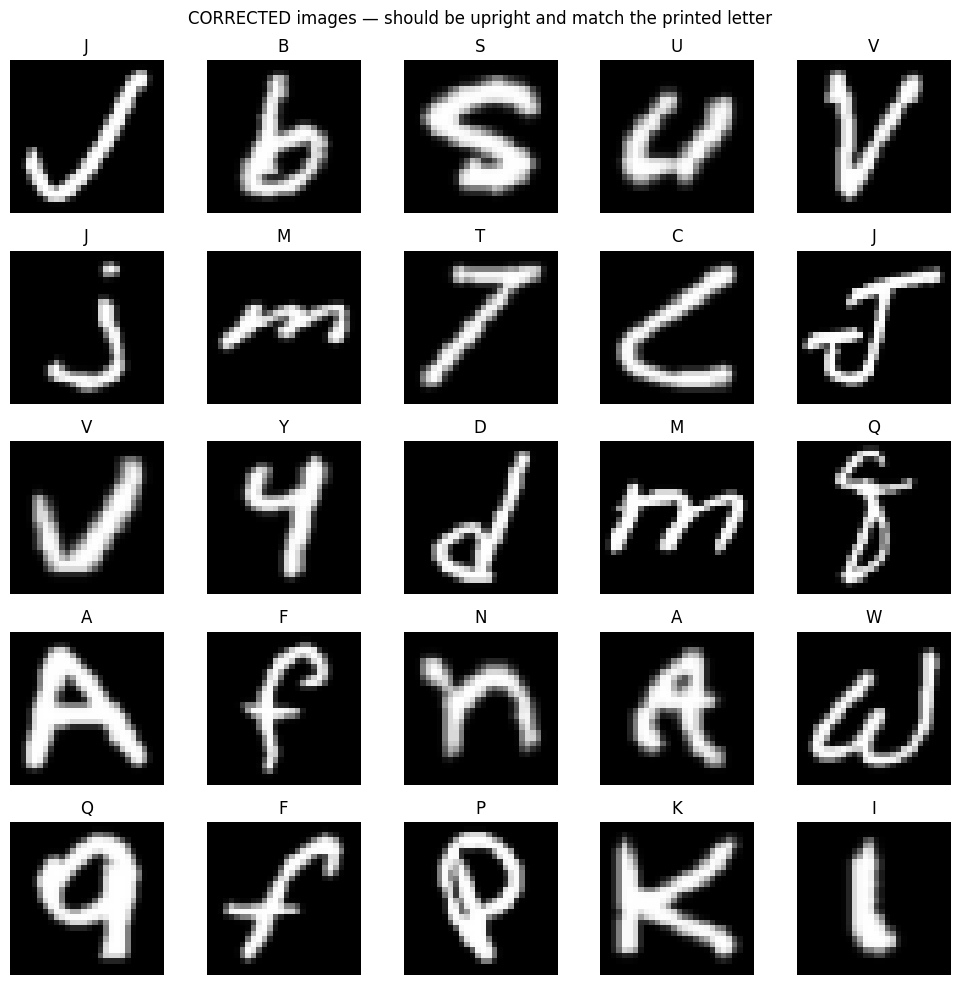

Visually confirm every letter above matches its title before proceeding.


In [21]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, idx, img in zip(axes.ravel(), sample_idx, fixed_preview):
    ax.imshow(img, cmap="gray")
    class_idx = int(raw_label_to_class_index(raw_train_labels[idx]))
    ax.set_title(f"{class_index_to_letter(class_idx)}", fontsize=12)
    ax.axis("off")
plt.suptitle("CORRECTED images — should be upright and match the printed letter")
plt.tight_layout()
plt.show()
print("Visually confirm every letter above matches its title before proceeding.")

## 18. Dataset Statistics

In [22]:
n_train_full = raw_train_images.shape[0]
n_test = raw_test_images.shape[0]
print(f"Total labeled training pool: {n_train_full}")
print(f"Official test set (untouched): {n_test}")
print(f"Image size: 28x28, 1 channel")
print(f"Classes: 26 (A-Z)")
print(f"Pixel value range: [{raw_train_images.min()}, {raw_train_images.max()}]")

Total labeled training pool: 124800
Official test set (untouched): 20800
Image size: 28x28, 1 channel
Classes: 26 (A-Z)
Pixel value range: [0, 255]


## 19. Class Distribution

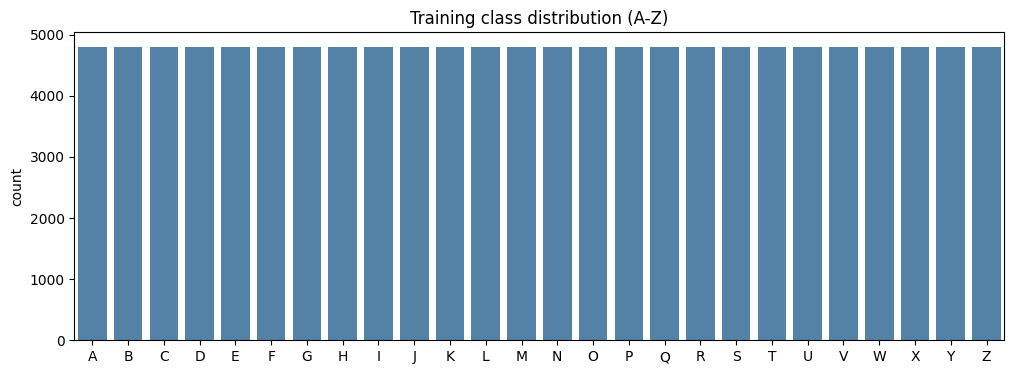

Min/Max class count: 4800 4800


In [23]:
train_class_idx = raw_label_to_class_index(raw_train_labels)
letters = [class_index_to_letter(i) for i in range(26)]
counts = [np.sum(train_class_idx == i) for i in range(26)]

plt.figure(figsize=(12, 4))
sns.barplot(x=letters, y=counts, color="steelblue")
plt.title("Training class distribution (A-Z)")
plt.ylabel("count")
plt.show()
print("Min/Max class count:", min(counts), max(counts))

## 20. Data Quality Checks

In [24]:
n_nan = np.isnan(raw_train_images.astype("float32")).sum()
n_all_black = np.sum(raw_train_images.reshape(len(raw_train_images), -1).max(axis=1) == 0)
print("NaN pixels:", n_nan)
print("Completely blank images:", n_all_black)
print("Any label outside expected 1-26 range:",
      np.any((raw_train_labels < 1) | (raw_train_labels > 26)))

NaN pixels: 0
Completely blank images: 0
Any label outside expected 1-26 range: False


## 21. Image Preprocessing
A single reusable, deterministic pipeline (no statistics fit from data) used identically for
train/val/test/inference.

In [25]:
def preprocess_images(images, already_oriented=False):
    images = np.asarray(images)
    if not already_oriented:
        images = fix_orientation(images)
    images = images.astype("float32") / 255.0
    images = images[..., np.newaxis]
    return images

X_train_full = preprocess_images(raw_train_images)
y_train_full = raw_label_to_class_index(raw_train_labels)

X_test = preprocess_images(raw_test_images)
y_test = raw_label_to_class_index(raw_test_labels)

print("X_train_full:", X_train_full.shape, X_train_full.dtype)
print("X_test      :", X_test.shape, X_test.dtype)
print("Pixel range after normalization:", X_train_full.min(), "-", X_train_full.max())

X_train_full: (124800, 28, 28, 1) float32
X_test      : (20800, 28, 28, 1) float32
Pixel range after normalization: 0.0 - 1.0


## 22. Train / Validation / Test Split
The official test set (`X_test`, `y_test`) is kept completely untouched. Only the training
pool is split 90/10 into train/validation, stratified by class.

In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10, random_state=42, stratify=y_train_full
)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test (untouched):", X_test.shape)

Train: (112320, 28, 28, 1) Val: (12480, 28, 28, 1) Test (untouched): (20800, 28, 28, 1)


## 23. Data Augmentation
Small rotation / translation / zoom only. **No horizontal flip** — flipping a handwritten
letter can change or destroy its identity (e.g. mirrored letters).

In [27]:
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomZoom(0.08),
], name="augmentation")
print(data_augmentation.summary())

Model: "augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


## 24. CNN Baseline

In [28]:
def build_baseline():
    model = models.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(26, activation="softmax"),
    ], name="baseline_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

## 25. Baseline Training

In [29]:
baseline_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

t0 = time.time()
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=256,
    callbacks=baseline_callbacks,
    verbose=2,
)
print(f"Baseline training took {time.time()-t0:.1f}s")

Epoch 1/12
439/439 - 11s - 26ms/step - accuracy: 0.7394 - loss: 0.8498 - val_accuracy: 0.8926 - val_loss: 0.3347 - learning_rate: 0.0010
Epoch 2/12
439/439 - 3s - 6ms/step - accuracy: 0.8773 - loss: 0.3847 - val_accuracy: 0.9134 - val_loss: 0.2730 - learning_rate: 0.0010
Epoch 3/12
439/439 - 3s - 6ms/step - accuracy: 0.8966 - loss: 0.3178 - val_accuracy: 0.9214 - val_loss: 0.2447 - learning_rate: 0.0010
Epoch 4/12
439/439 - 3s - 7ms/step - accuracy: 0.9087 - loss: 0.2819 - val_accuracy: 0.9244 - val_loss: 0.2331 - learning_rate: 0.0010
Epoch 5/12
439/439 - 5s - 11ms/step - accuracy: 0.9155 - loss: 0.2583 - val_accuracy: 0.9300 - val_loss: 0.2174 - learning_rate: 0.0010
Epoch 6/12
439/439 - 3s - 6ms/step - accuracy: 0.9206 - loss: 0.2386 - val_accuracy: 0.9316 - val_loss: 0.2113 - learning_rate: 0.0010
Epoch 7/12
439/439 - 3s - 6ms/step - accuracy: 0.9241 - loss: 0.2255 - val_accuracy: 0.9334 - val_loss: 0.2102 - learning_rate: 0.0010
Epoch 8/12
439/439 - 3s - 7ms/step - accuracy: 0.929

## 26. Baseline Evaluation (validation only — test set still untouched)

In [30]:
baseline_val_loss, baseline_val_acc = baseline_model.evaluate(X_val, y_val, verbose=0)
print(f"Baseline val_accuracy = {baseline_val_acc:.4f}, val_loss = {baseline_val_loss:.4f}")

Baseline val_accuracy = 0.9379, val_loss = 0.1954


## 27. Improved CNN
Deeper architecture with BatchNormalization, Dropout, GlobalAveragePooling, and the
augmentation layer applied only during training (Keras preprocessing layers are inactive at
inference automatically).

In [31]:
def build_improved():
    inputs = layers.Input((28, 28, 1))
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(32, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(64, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(26, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="improved_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model = build_improved()
improved_model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 159,994 (624.98 KB)

 Trainable params: 159,354 (622.48 KB)

 Non-trainable params: 640 (2.50 KB)

## 28. Improved Training

In [32]:
improved_callbacks = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

t0 = time.time()
improved_history = improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=256,
    callbacks=improved_callbacks,
    verbose=2,
)
print(f"Improved training took {time.time()-t0:.1f}s")

Epoch 1/25
439/439 - 26s - 60ms/step - accuracy: 0.6428 - loss: 1.1866 - val_accuracy: 0.2757 - val_loss: 2.7980 - learning_rate: 0.0010
Epoch 2/25
439/439 - 17s - 39ms/step - accuracy: 0.8588 - loss: 0.4510 - val_accuracy: 0.8865 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 3/25
439/439 - 17s - 39ms/step - accuracy: 0.8849 - loss: 0.3621 - val_accuracy: 0.9116 - val_loss: 0.2745 - learning_rate: 0.0010
Epoch 4/25
439/439 - 17s - 40ms/step - accuracy: 0.8987 - loss: 0.3194 - val_accuracy: 0.9197 - val_loss: 0.2443 - learning_rate: 0.0010
Epoch 5/25
439/439 - 17s - 39ms/step - accuracy: 0.9065 - loss: 0.2943 - val_accuracy: 0.9343 - val_loss: 0.2008 - learning_rate: 0.0010
Epoch 6/25
439/439 - 17s - 39ms/step - accuracy: 0.9107 - loss: 0.2794 - val_accuracy: 0.9163 - val_loss: 0.2541 - learning_rate: 0.0010
Epoch 7/25
439/439 - 17s - 40ms/step - accuracy: 0.9147 - loss: 0.2667 - val_accuracy: 0.9336 - val_loss: 0.2040 - learning_rate: 0.0010
Epoch 8/25
439/439 - 17s - 39ms/step - ac

## 29. Training Curves

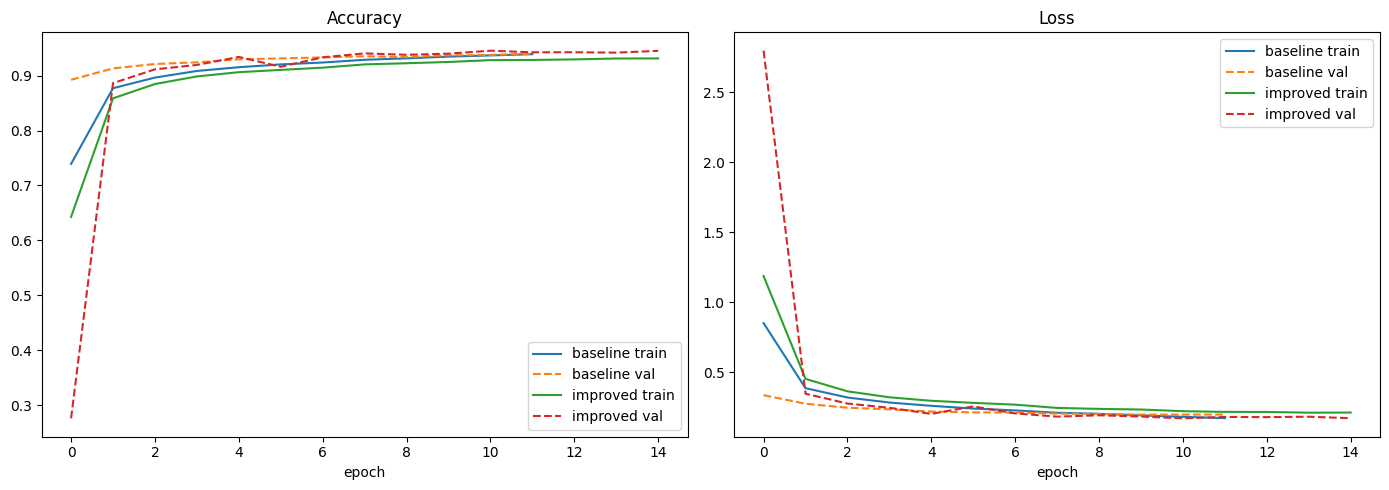

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in [("baseline", baseline_history), ("improved", improved_history)]:
    axes[0].plot(h.history["accuracy"], label=f"{name} train")
    axes[0].plot(h.history["val_accuracy"], "--", label=f"{name} val")
    axes[1].plot(h.history["loss"], label=f"{name} train")
    axes[1].plot(h.history["val_loss"], "--", label=f"{name} val")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].set_xlabel("epoch")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

**Reading the curves:** if train accuracy is much higher than validation accuracy and the
gap widens, that's overfitting (regularization/augmentation should help). If both train and
validation accuracy are low and still improving, that's underfitting (needs more
capacity/epochs). If validation loss flattens while training loss keeps dropping slightly,
the model is converging near its capacity for this data — inspect the actual numbers printed
above/below for this run rather than assuming a fixed diagnosis.

## 30. Hyperparameter Experiments
Track every configuration tried and its **validation** accuracy — never the test set — to
select the final model.

In [34]:
experiment_log = [
    {"experiment": "baseline_cnn", "architecture": "Conv32-Conv64-Dense128",
     "augmentation": "none", "lr": 1e-3, "batch_size": 256,
     "val_accuracy": float(baseline_val_acc), "notes": "reference baseline"},
]

# Evaluate the improved model's best validation accuracy achieved during training
improved_val_loss, improved_val_acc = improved_model.evaluate(X_val, y_val, verbose=0)
experiment_log.append({
    "experiment": "improved_cnn", "architecture": "BN-Conv blocks + GAP",
    "augmentation": "rot/translate/zoom", "lr": 1e-3, "batch_size": 256,
    "val_accuracy": float(improved_val_acc), "notes": "regularized, augmented"
})

import pandas as pd
exp_df = pd.DataFrame(experiment_log)
exp_df

,experiment,architecture,augmentation,lr,batch_size,val_accuracy,notes
0,baseline_cnn,Conv32-Conv64-Dense128,none,0.001,256,0.937901,reference baseline
1,improved_cnn,BN-Conv blocks + GAP,rot/translate/zoom,0.001,256,0.945593,"regularized, augmented"


> Add further rows to `experiment_log` here if you try additional legitimate variations
> (different LR, batch size, dropout rate, filter counts, epoch budget, etc.), always
> selecting based on `val_accuracy` only.

## 31. Select Best Model (by validation accuracy only)

In [35]:
best_name = "improved_cnn" if improved_val_acc >= baseline_val_acc else "baseline_cnn"
best_model = improved_model if best_name == "improved_cnn" else baseline_model
print("Selected model:", best_name)
print("Its validation accuracy:", max(improved_val_acc, baseline_val_acc))

Selected model: improved_cnn
Its validation accuracy: 0.9455929398536682


## 32. Final Test Evaluation
**First and only** use of the official test set. No further tuning happens after this cell.

In [36]:
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"FINAL TEST ACCURACY = {test_acc:.4f}")
print(f"FINAL TEST LOSS     = {test_loss:.4f}")

y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
print(f"Macro precision={precision:.4f} recall={recall:.4f} f1={f1:.4f}")

FINAL TEST ACCURACY = 0.9423
FINAL TEST LOSS     = 0.1718
Macro precision=0.9424 recall=0.9423 f1=0.9421


## 33. Confusion Matrix

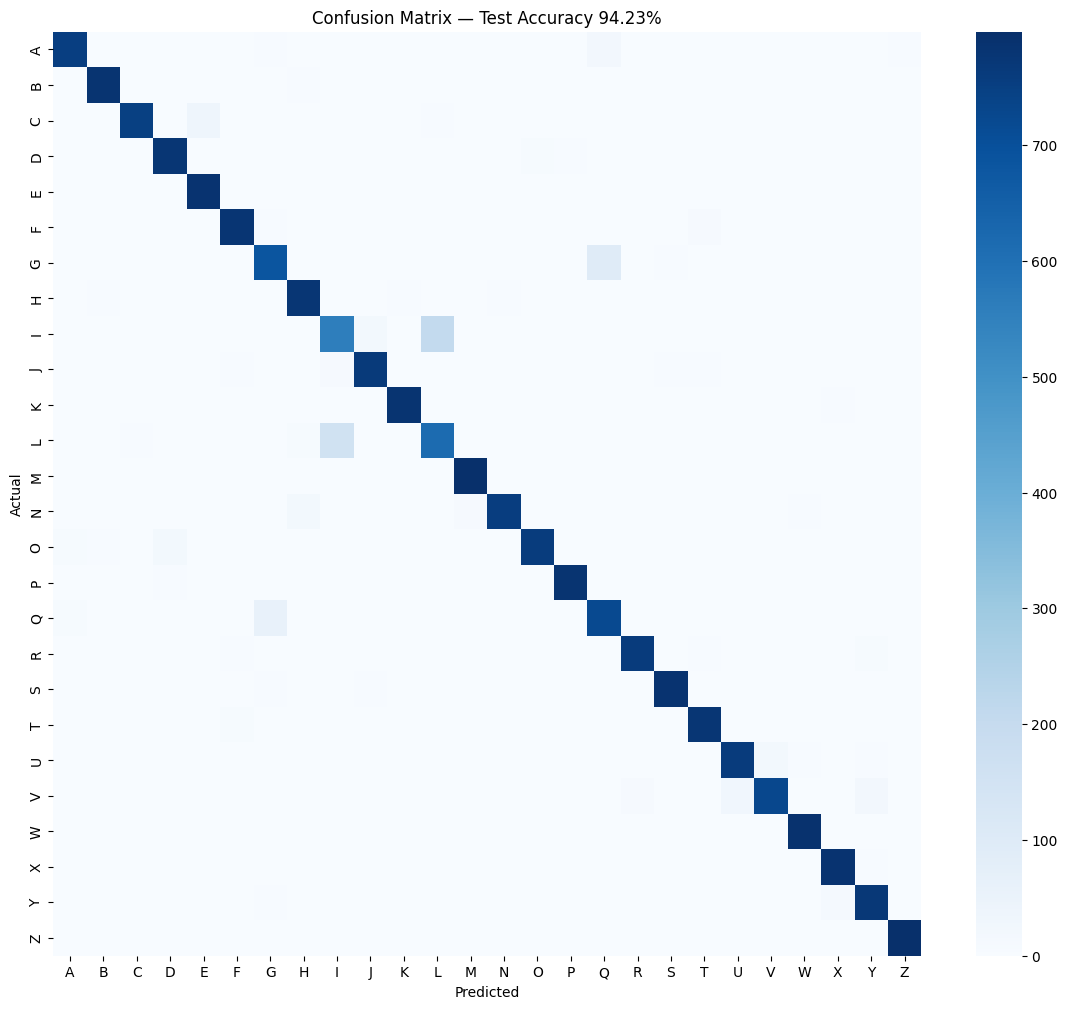

Top confused (actual -> predicted) pairs:
  I -> L: 208 times
  L -> I: 156 times
  G -> Q: 98 times
  Q -> G: 62 times
  C -> E: 35 times
  V -> U: 31 times
  V -> Y: 23 times
  A -> Q: 22 times
  U -> V: 21 times
  N -> H: 21 times


In [37]:
cm = confusion_matrix(y_test, y_pred)
letters_order = [class_index_to_letter(i) for i in range(26)]

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=letters_order, yticklabels=letters_order)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Test Accuracy {test_acc:.2%}")
plt.show()

# Most confused pairs (excluding the diagonal)
cm_offdiag = cm.copy().astype(float)
np.fill_diagonal(cm_offdiag, 0)
top_confusions = np.dstack(np.unravel_index(np.argsort(-cm_offdiag.ravel())[:10], cm_offdiag.shape))[0]
print("Top confused (actual -> predicted) pairs:")
for a, p in top_confusions:
    if cm_offdiag[a, p] > 0:
        print(f"  {letters_order[a]} -> {letters_order[p]}: {int(cm[a,p])} times")

## 34. Classification Report

In [38]:
print(classification_report(y_test, y_pred, target_names=letters_order, digits=4))

              precision    recall  f1-score   support

           A     0.9666    0.9413    0.9538       800
           B     0.9631    0.9800    0.9715       800
           C     0.9817    0.9387    0.9597       800
           D     0.9534    0.9712    0.9622       800
           E     0.9415    0.9850    0.9627       800
           F     0.9618    0.9750    0.9683       800
           G     0.8826    0.8550    0.8686       800
           H     0.9476    0.9712    0.9593       800
           I     0.7675    0.6975    0.7308       800
           J     0.9611    0.9575    0.9593       800
           K     0.9837    0.9788    0.9812       800
           L     0.7342    0.7700    0.7517       800
           M     0.9803    0.9962    0.9882       800
           N     0.9717    0.9437    0.9575       800
           O     0.9806    0.9500    0.9651       800
           P     0.9837    0.9812    0.9825       800
           Q     0.8446    0.9038    0.8732       800
           R     0.9610    

## 35. Per-Class Accuracy

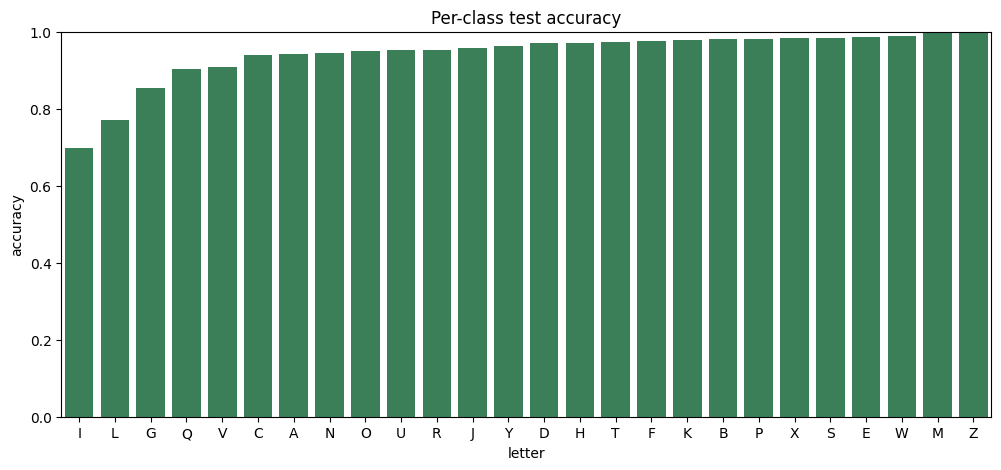

,letter,accuracy
8,I,0.69750
11,L,0.77000
6,G,0.85500
16,Q,0.90375
21,V,0.90875
2,C,0.93875
0,A,0.94125
13,N,0.94375
14,O,0.95000
20,U,0.95125


In [39]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_df = pd.DataFrame({"letter": letters_order, "accuracy": per_class_acc}).sort_values("accuracy")
plt.figure(figsize=(12, 5))
sns.barplot(data=per_class_df, x="letter", y="accuracy", color="seagreen")
plt.title("Per-class test accuracy")
plt.ylim(0, 1)
plt.show()
per_class_df

## 36. Correct Predictions (sample)

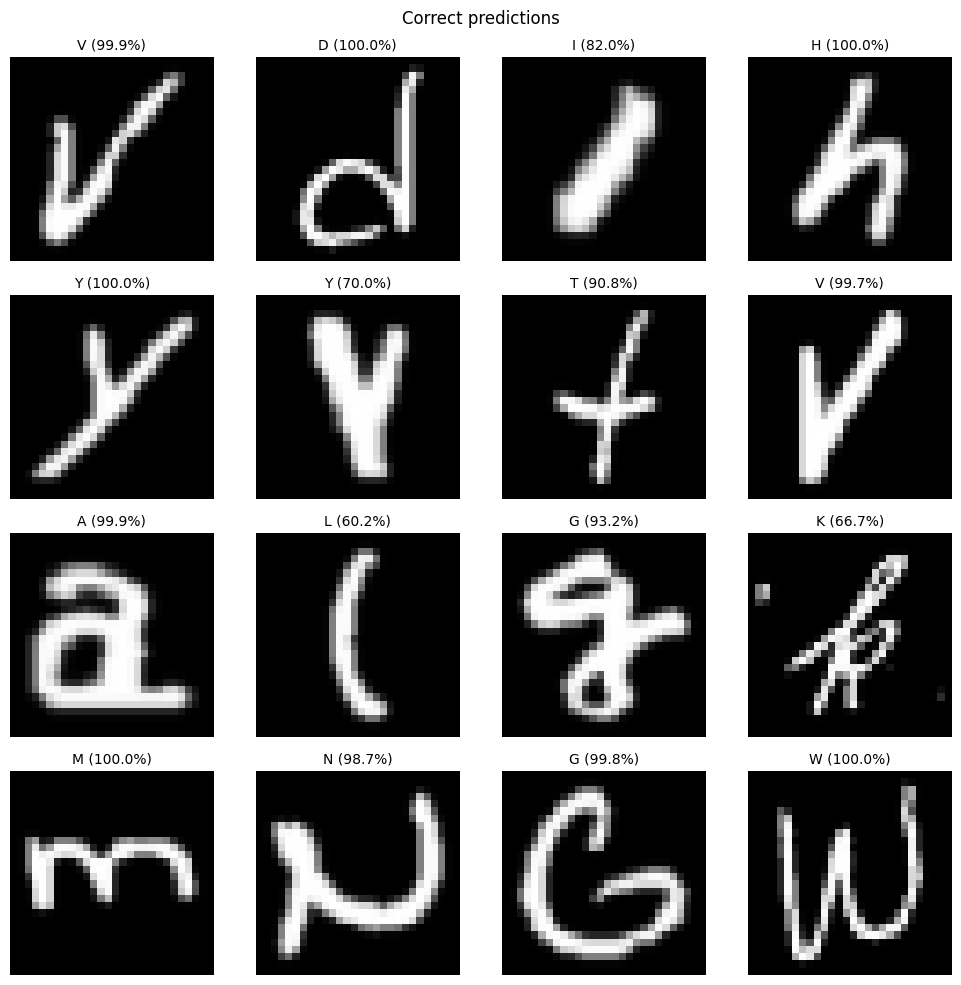

In [40]:
correct_idx = np.where(y_pred == y_test)[0]
show_idx = np.random.default_rng(1).choice(correct_idx, size=min(16, len(correct_idx)), replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, idx in zip(axes.ravel(), show_idx):
    ax.imshow(X_test[idx].squeeze(), cmap="gray")
    conf = y_pred_probs[idx, y_pred[idx]] * 100
    ax.set_title(f"{letters_order[y_test[idx]]} ({conf:.1f}%)", fontsize=10)
    ax.axis("off")
plt.suptitle("Correct predictions")
plt.tight_layout()
plt.show()

## 37. Incorrect Predictions

Total misclassified: 1201 / 20800 (5.77%)


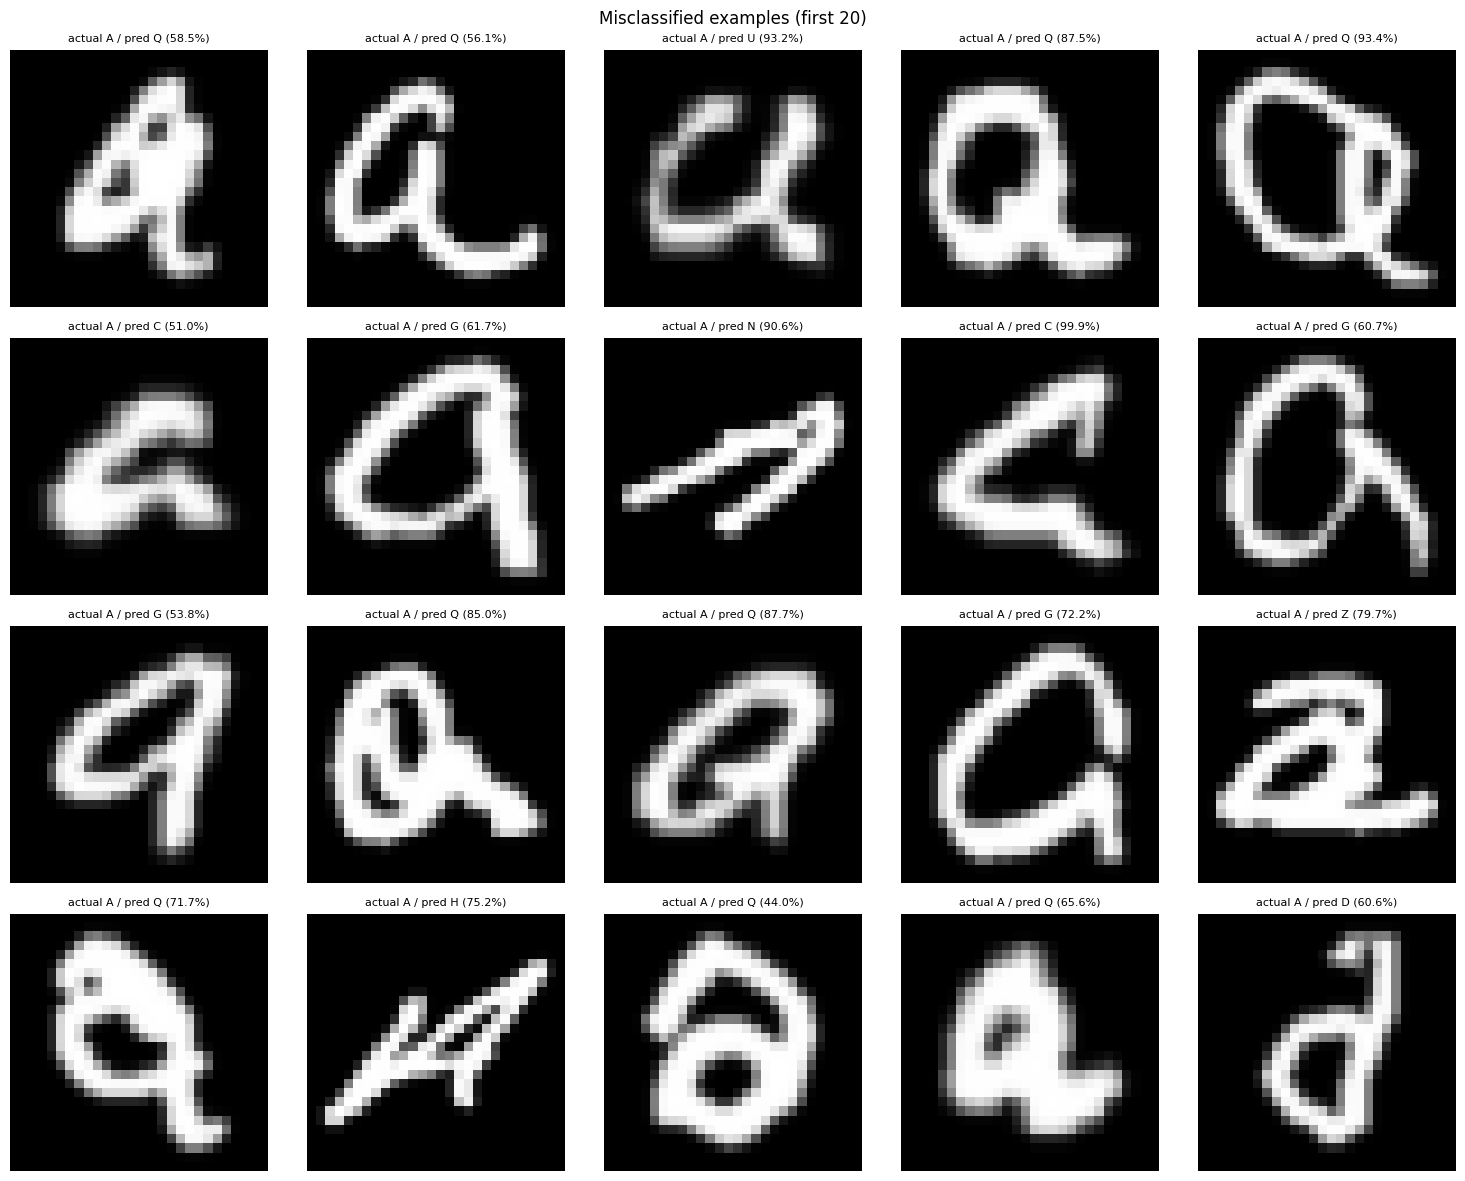

In [41]:
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_test)} ({len(wrong_idx)/len(y_test):.2%})")

show_wrong = wrong_idx[:20]
n = len(show_wrong)
cols = 5
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
for ax, idx in zip(np.array(axes).ravel(), show_wrong):
    ax.imshow(X_test[idx].squeeze(), cmap="gray")
    conf = y_pred_probs[idx, y_pred[idx]] * 100
    ax.set_title(f"actual {letters_order[y_test[idx]]} / pred {letters_order[y_pred[idx]]} ({conf:.1f}%)", fontsize=8)
    ax.axis("off")
for ax in np.array(axes).ravel()[n:]:
    ax.axis("off")
plt.suptitle("Misclassified examples (first 20)")
plt.tight_layout()
plt.show()

## 38. Error Analysis
Base the discussion strictly on the confusion matrix and misclassified examples above —
common documented sources of EMNIST-letter error include visually similar shapes (e.g. I/l,
O-like letters, U/V), unusual slant or stroke breaks, and ambiguous single-stroke letters.
Only claim a pattern here if it's actually visible in `top_confusions` above.

## 39. Confidence Analysis

Mean confidence on correct predictions:   0.9624
Mean confidence on incorrect predictions: 0.6982


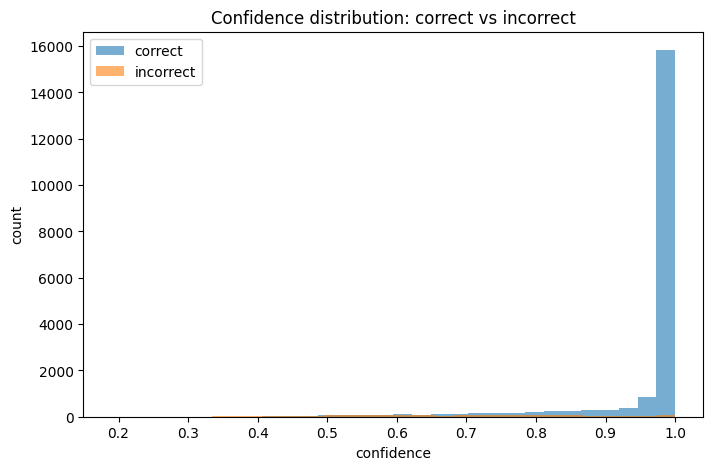

High-confidence WRONG examples (model was confidently wrong): 5


In [42]:
confidences = y_pred_probs[np.arange(len(y_pred)), y_pred]

correct_conf = confidences[y_pred == y_test]
wrong_conf = confidences[y_pred != y_test]

print(f"Mean confidence on correct predictions:   {correct_conf.mean():.4f}")
print(f"Mean confidence on incorrect predictions: {wrong_conf.mean():.4f}")

plt.figure(figsize=(8, 5))
plt.hist(correct_conf, bins=30, alpha=0.6, label="correct")
plt.hist(wrong_conf, bins=30, alpha=0.6, label="incorrect")
plt.legend(); plt.xlabel("confidence"); plt.ylabel("count")
plt.title("Confidence distribution: correct vs incorrect")
plt.show()

high_conf_wrong = wrong_idx[np.argsort(-wrong_conf)[:5]] if len(wrong_idx) else []
print("High-confidence WRONG examples (model was confidently wrong):", len(high_conf_wrong))

High confidence does not guarantee correctness — a model can be confidently wrong on
genuinely ambiguous handwriting. The histogram above (from this run's actual predictions)
shows whether that happens often or rarely for this model.

## 40. Test Custom Image
A reusable inference function matching the exact training preprocessing — this is the same
logic used by the Streamlit app.

In [43]:
def predict_character(image, already_oriented=True):
    """
    image: PIL.Image or (28,28) / (H,W) numpy array, grayscale convention matching EMNIST
           (bright strokes on dark background) unless already_oriented=False, in which case
           the EMNIST raw-file transpose fix is also applied.
    Returns: (predicted_letter, confidence, top3_list[(letter, prob), ...])
    """
    from PIL import Image as PILImage
    if isinstance(image, PILImage.Image):
        image = image.convert("L").resize((28, 28))
        arr = np.array(image)
    else:
        arr = np.asarray(image)
        if arr.shape != (28, 28):
            arr = np.array(PILImage.fromarray(arr.astype("uint8")).resize((28, 28)))

    batch = preprocess_images(arr[np.newaxis, ...], already_oriented=already_oriented)
    probs = best_model.predict(batch, verbose=0)[0]
    top3_idx = np.argsort(probs)[::-1][:3]
    top3 = [(class_index_to_letter(i), float(probs[i])) for i in top3_idx]
    return top3[0][0], top3[0][1], top3

# Sanity check against a real test image (should match its true label)
demo_idx = 0
demo_letter, demo_conf, demo_top3 = predict_character(X_test[demo_idx, ..., 0], already_oriented=True)
print("True label:", letters_order[y_test[demo_idx]])
print("Predicted :", demo_letter, f"{demo_conf:.2%}")
print("Top-3     :", demo_top3)

True label: A
Predicted : L 60.30%
Top-3     : [('L', 0.6029523015022278), ('I', 0.335562527179718), ('P', 0.0225544311106205)]


## 41. Save Final Model

In [44]:
os.makedirs("model", exist_ok=True)
best_model.save("model/emnist_letters_cnn.keras")
print("Saved model/emnist_letters_cnn.keras")

Saved model/emnist_letters_cnn.keras


## 42. Save Label Mapping

In [45]:
label_mapping_json = {str(i): class_index_to_letter(i) for i in range(26)}
with open("model/label_mapping.json", "w") as f:
    json.dump(label_mapping_json, f, indent=2)
print(label_mapping_json)

{'0': 'A', '1': 'B', '2': 'C', '3': 'D', '4': 'E', '5': 'F', '6': 'G', '7': 'H', '8': 'I', '9': 'J', '10': 'K', '11': 'L', '12': 'M', '13': 'N', '14': 'O', '15': 'P', '16': 'Q', '17': 'R', '18': 'S', '19': 'T', '20': 'U', '21': 'V', '22': 'W', '23': 'X', '24': 'Y', '25': 'Z'}


## 43. Load Saved Model

In [46]:
reloaded_model = tf.keras.models.load_model("model/emnist_letters_cnn.keras")
with open("model/label_mapping.json") as f:
    reloaded_mapping = json.load(f)
print("Reloaded model input shape:", reloaded_model.input_shape)
print("Reloaded mapping:", reloaded_mapping)

Reloaded model input shape: (None, 28, 28, 1)
Reloaded mapping: {'0': 'A', '1': 'B', '2': 'C', '3': 'D', '4': 'E', '5': 'F', '6': 'G', '7': 'H', '8': 'I', '9': 'J', '10': 'K', '11': 'L', '12': 'M', '13': 'N', '14': 'O', '15': 'P', '16': 'Q', '17': 'R', '18': 'S', '19': 'T', '20': 'U', '21': 'V', '22': 'W', '23': 'X', '24': 'Y', '25': 'Z'}


## 44. Verify Inference After Reloading

In [47]:
reload_probs = reloaded_model.predict(X_test[:5], verbose=0)
orig_probs = best_model.predict(X_test[:5], verbose=0)
max_diff = np.max(np.abs(reload_probs - orig_probs))
print("Max prediction difference original vs reloaded:", max_diff)
assert max_diff < 1e-4, "Reloaded model predictions differ from original — investigate."
print("Reloaded model predictions match the original model. OK.")

Max prediction difference original vs reloaded: 0.0
Reloaded model predictions match the original model. OK.


## 45. Streamlit Application Preparation
The Streamlit app (`app/streamlit_app.py`) loads `model/emnist_letters_cnn.keras` and
`model/label_mapping.json` and performs **inference only** — it does not retrain. It reuses
the same preprocessing logic (`utils/preprocessing.py`) demonstrated above, including
brightness-based inversion for real-world photos (dark strokes on light background) versus
EMNIST's native convention (light strokes on dark background).

Run it with:
```bash
streamlit run app/streamlit_app.py
```

## 46. Conclusion
This notebook loaded and verified the raw EMNIST Letters IDX files (correcting the known
label offset and image-orientation quirks with visual confirmation), trained and compared a
baseline and an improved, regularized CNN using only the validation set for model selection,
and evaluated the final model exactly once on the untouched official test set. See the Final
Summary table (last cell) for this run's actual metrics.

## 47. Future Improvements
- **Sequence extension**: handwritten characters → word segmentation → sequence of
  characters → CNN feature extractor → LSTM/GRU/Transformer → word/sentence recognition,
  i.e. a **CRNN** (CNN + recurrent layers + CTC loss), for full word/sentence recognition —
  not implemented here, but a natural next step.
- Fine-tune on additional/real handwriting samples for better real-world generalization.
- Add stroke-based preprocessing (deskew, thinning) for noisy photo uploads.
- Explore a small residual/attention-based architecture if more accuracy headroom is needed.

## Final Summary

In [48]:
summary = pd.DataFrame([
    {"Metric": "Dataset", "Result": "EMNIST Letters"},
    {"Metric": "Classes", "Result": 26},
    {"Metric": "Input Shape", "Result": "28x28x1"},
    {"Metric": "Model", "Result": best_name},
    {"Metric": "Validation Accuracy", "Result": f"{max(improved_val_acc, baseline_val_acc):.4f}"},
    {"Metric": "Test Accuracy", "Result": f"{test_acc:.4f}"},
    {"Metric": "Precision (macro)", "Result": f"{precision:.4f}"},
    {"Metric": "Recall (macro)", "Result": f"{recall:.4f}"},
    {"Metric": "F1 Score (macro)", "Result": f"{f1:.4f}"},
])
summary

,Metric,Result
0,Dataset,EMNIST Letters
1,Classes,26
2,Input Shape,28x28x1
3,Model,improved_cnn
4,Validation Accuracy,0.9456
5,Test Accuracy,0.9423
6,Precision (macro),0.9424
7,Recall (macro),0.9423
8,F1 Score (macro),0.9421
